# 📊 TUGAS 2B — Scraping & Analisis Review per Tahun Aplikasi Honest

---

**Dataset:** `cleandata.csv` + `df_honest_reviews_id.csv` (untuk kolom tanggal)  
**Fokus:** Demo scraping & analisis tren review per tahun  
**Referensi:** Pola analisis temporal dari [data-analysis-on-indonesia-startup-apps-reviews](https://github.com/rezkyyayang) (Rezky Yayang)

## 📚 Tujuan Pembelajaran

1. Memahami cara melakukan scraping review dari Google Play Store
2. Menggabungkan dataset untuk mendapatkan informasi temporal (tanggal review)
3. Menganalisis tren jumlah review per tahun (N = Review per Year)
4. Membuat visualisasi distribusi score berdasarkan tahun
5. Mengidentifikasi perubahan sentimen pengguna dari tahun ke tahun
6. Menganalisis frekuensi kata dengan WordCloud

## 1) 📦 Install & Import Library

In [30]:
%pip install google-play-scraper matplotlib seaborn wordcloud Sastrawi -q

Note: you may need to restart the kernel to use updated packages.


In [31]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## 2) 🌐 Demo Scraping Review Google Play Store

Berikut adalah contoh kode untuk melakukan scraping review aplikasi Honest dari Google Play Store menggunakan library `google-play-scraper`.

> ⚠️ **Catatan:** Kode scraping di-comment agar tidak dijalankan berulang. Review yang sudah discraping tersimpan di `cleandata.csv`.

In [32]:
from google_play_scraper import app, Sort, reviews

# # ── Ambil info aplikasi ──
# app_info = app('com.honestbank.android', lang='id', country='id')
# print(f"Nama App   : {app_info['title']}")
# print(f"Rating     : {app_info['score']:.2f}")
# print(f"Total Review: {app_info['ratings']:,}")
# print(f"Installs   : {app_info['installs']}")

# # ── Scraping review (contoh: 5000 review) ──
# result, continuation_token = reviews(
#     'com.honestbank.android',
#     lang='id',
#     country='id',
#     sort=Sort.NEWEST,
#     count=5000
# )
# df_scraped = pd.DataFrame(result)
# print(f"\nBerhasil scraping {len(df_scraped)} review!")
# df_scraped.to_csv('honest_reviews_scraped.csv', index=False)

print("📌 Demo scraping (di-comment untuk efisiensi)")
print("📌 Dataset yang digunakan: cleandata.csv")

📌 Demo scraping (di-comment untuk efisiensi)
📌 Dataset yang digunakan: cleandata.csv


## 3) 📂 Load Dataset & Merge Tanggal

Dataset utama `cleandata.csv` tidak memiliki kolom tanggal. Untuk analisis per tahun, kita merge dengan `df_honest_reviews_id.csv` yang memiliki kolom `at` (tanggal review).

In [33]:
# ── Load dataset utama ──
df = pd.read_csv('cleandata.csv')
print(f"📌 Dataset cleandata.csv dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom")

# ── Load dataset dengan tanggal ──
df_raw = pd.read_csv('../Week 2/df_honest_reviews_id.csv')
df_raw_dedup = df_raw.drop_duplicates(subset='content', keep='first')[['content', 'at']]
print(f"📌 Dataset df_honest_reviews_id.csv: {len(df_raw):,} baris → {len(df_raw_dedup):,} unik")

# ── Merge untuk mendapatkan kolom tanggal ──
df = df.merge(df_raw_dedup, on='content', how='left')
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year

print(f"\n✅ Merge berhasil! Dataset final: {len(df):,} baris")
print(f"📌 Rentang tanggal: {df['at'].min().strftime('%Y-%m-%d')} s/d {df['at'].max().strftime('%Y-%m-%d')}")
print(f"📌 Tahun tersedia : {sorted(df['year'].unique())}")
print("=" * 60)
df.head()

📌 Dataset cleandata.csv dimuat: 39,164 baris × 4 kolom
📌 Dataset df_honest_reviews_id.csv: 39,324 baris → 37,471 unik

✅ Merge berhasil! Dataset final: 39,164 baris
📌 Rentang tanggal: 2023-02-16 s/d 2026-03-13
📌 Tahun tersedia : [np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


,score,content,text_final,reviewCreatedVersion,at,year
0,5,ini adalah pertama kali saya menggunakan kartu...,kali kartu kredit cocok anak muda update alam ...,3.831.0,2026-03-13 16:27:30,2026
1,5,"pengajuan berhasil, pelayanan utk CS atas nama...",hasil layan cs nama sangat sopan jelas sangat ...,3.833.1,2026-03-13 16:22:21,2026
2,5,Pengajuan cepat dan aman..,cepat aman,3.833.1,2026-03-13 16:21:04,2026
3,5,cs Ridwan terbaik,cs baik,3.833.1,2026-03-13 16:16:58,2026
4,5,penjelasan yang baik oleh mba rima,jelas baik,3.833.1,2026-03-13 16:11:32,2026


## 4) 📋 Statistik Deskriptif

Ringkasan statistik dataset termasuk distribusi review per tahun.

In [34]:
print("📌 Statistik Deskriptif:")
print("=" * 60)
print(f"Total review       : {len(df):,}")
print(f"Rata-rata score    : {df['score'].mean():.2f}")
print(f"Median score       : {df['score'].median():.1f}")
print(f"Std dev score      : {df['score'].std():.2f}")
print(f"Versi unik         : {df['reviewCreatedVersion'].nunique()}")
print(f"Missing versi      : {df['reviewCreatedVersion'].isnull().sum():,}")

print(f"\n📌 Distribusi Review per Tahun:")
print("=" * 60)
for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    n = len(subset)
    avg = subset['score'].mean()
    bar = '█' * int(n / df['year'].value_counts().max() * 40)
    print(f"  {year}: {bar} {n:,} review (avg score: {avg:.2f})")

print(f"\n📌 Distribusi Score:")
print("=" * 60)
for score, count in df['score'].value_counts().sort_index().items():
    bar = '█' * int(count / df['score'].value_counts().max() * 40)
    print(f"  Score {score}: {bar} {count:,} ({count/len(df)*100:.1f}%)")

📌 Statistik Deskriptif:
Total review       : 39,164
Rata-rata score    : 4.62
Median score       : 5.0
Std dev score      : 1.12
Versi unik         : 171
Missing versi      : 5,063

📌 Distribusi Review per Tahun:
  2023: ████████████████████████████████████ 13,374 review (avg score: 4.60)
  2024: ████████████████████████████████████████ 14,609 review (avg score: 4.71)
  2025: ████████████████████████ 8,815 review (avg score: 4.45)
  2026: ██████ 2,366 review (avg score: 4.75)

📌 Distribusi Score:
  Score 1: ███ 2,961 (7.6%)
  Score 2:  464 (1.2%)
  Score 3:  561 (1.4%)
  Score 4:  715 (1.8%)
  Score 5: ████████████████████████████████████████ 34,463 (88.0%)


## 5) ⭐ Distribusi Score (Rating)

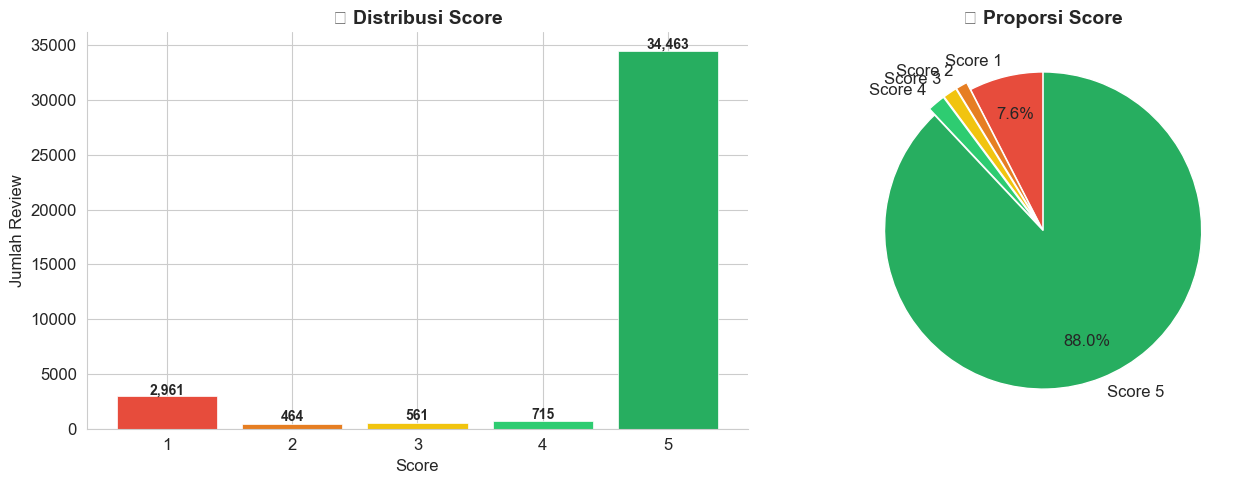


📌 Score 5 mendominasi: 34,463 review (88.0%)
📌 Review negatif (1-2): 3,425 (8.7%)


In [35]:
score_counts = df['score'].value_counts().sort_index()
colors_bar = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar Chart ──
bars = axes[0].bar(score_counts.index, score_counts.values, color=colors_bar,
                   edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_ylabel('Jumlah Review', fontsize=12)
axes[0].set_title('📊 Distribusi Score', fontsize=14, fontweight='bold')
for bar, val in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Pie Chart (fix overlap) ──
explode = [0.05 if v/score_counts.sum()*100 < 5 else 0 for v in score_counts.values]
def autopct_func(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''
axes[1].pie(score_counts.values, labels=[f'Score {s}' for s in score_counts.index],
            autopct=autopct_func, colors=colors_bar, startangle=90,
            explode=explode, pctdistance=0.75)
axes[1].set_title('📊 Proporsi Score', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Insight
dominant = score_counts.idxmax()
print(f"\n📌 Score {dominant} mendominasi: {score_counts[dominant]:,} review ({score_counts[dominant]/len(df)*100:.1f}%)")
print(f"📌 Review negatif (1-2): {score_counts[1]+score_counts[2]:,} ({(score_counts[1]+score_counts[2])/len(df)*100:.1f}%)")

## 6) 📊 N = Review per Tahun

Analisis utama: menghitung jumlah review (N) untuk setiap tahun. Pola ini mengikuti referensi dari notebook [data-analysis-on-indonesia-startup-apps-reviews](https://github.com/rezkyyayang) yang menggunakan `created_at` → `year` untuk analisis temporal.

> 📌 Kolom `at` dari `df_honest_reviews_id.csv` di-merge ke `cleandata.csv` untuk mendapatkan dimensi waktu.

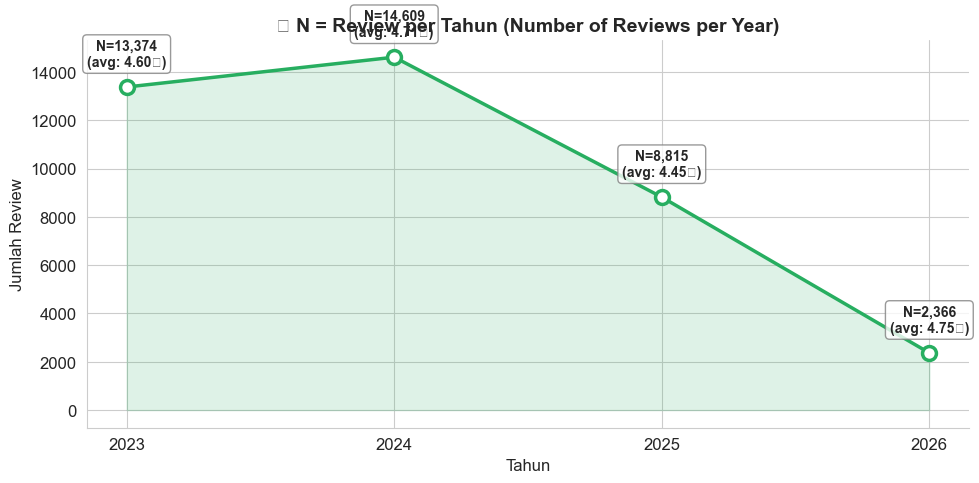


📌 Tahun dengan review terbanyak: 2024 (N=14,609)
📌 Tahun dengan review tersedikit: 2026 (N=2,366)
📌 Catatan: 2026 masih berjalan (data parsial s/d Maret 2026)


In [36]:
# ── N = Review per Tahun (line plot, gaya rezkyyayang) ──
year_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(year_counts.index, year_counts.values, marker='o', color='#27ae60',
        linewidth=2.5, markersize=10, markerfacecolor='white',
        markeredgewidth=2.5, markeredgecolor='#27ae60')
ax.fill_between(year_counts.index, year_counts.values, alpha=0.15, color='#27ae60')

ax.set_xlabel('Tahun', fontsize=12)
ax.set_ylabel('Jumlah Review', fontsize=12)
ax.set_title('📊 N = Review per Tahun (Number of Reviews per Year)', fontsize=14, fontweight='bold')
ax.set_xticks(year_counts.index)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate setiap titik
for yr, n in year_counts.items():
    avg = df[df['year'] == yr]['score'].mean()
    ax.annotate(f'N={n:,}\n(avg: {avg:.2f}⭐)',
                (yr, n), textcoords="offset points",
                xytext=(0, 15), ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

# ── Insight ──
peak_year = year_counts.idxmax()
print(f"\n📌 Tahun dengan review terbanyak: {peak_year} (N={year_counts[peak_year]:,})")
print(f"📌 Tahun dengan review tersedikit: {year_counts.idxmin()} (N={year_counts.min():,})")
print(f"📌 Catatan: 2026 masih berjalan (data parsial s/d Maret 2026)")

## 6b) 🎯 Ekstraksi Versi Aplikasi dengan Regex

Menggunakan **named capturing groups** dan `re.compile()` untuk mengekstrak komponen versi (major.minor.patch) dari kolom `reviewCreatedVersion`. Mendemonstrasikan penggunaan regex pada data terstruktur.

📌 Versi berhasil diekstrak: 34,101 dari 39,164 review
📌 Gagal diekstrak (NaN)   : 5,063

📊 Distribusi Major Version:
   v2.x.x : █████████████████ 12,454
   v3.x.x : ██████████████████████████████ 21,647


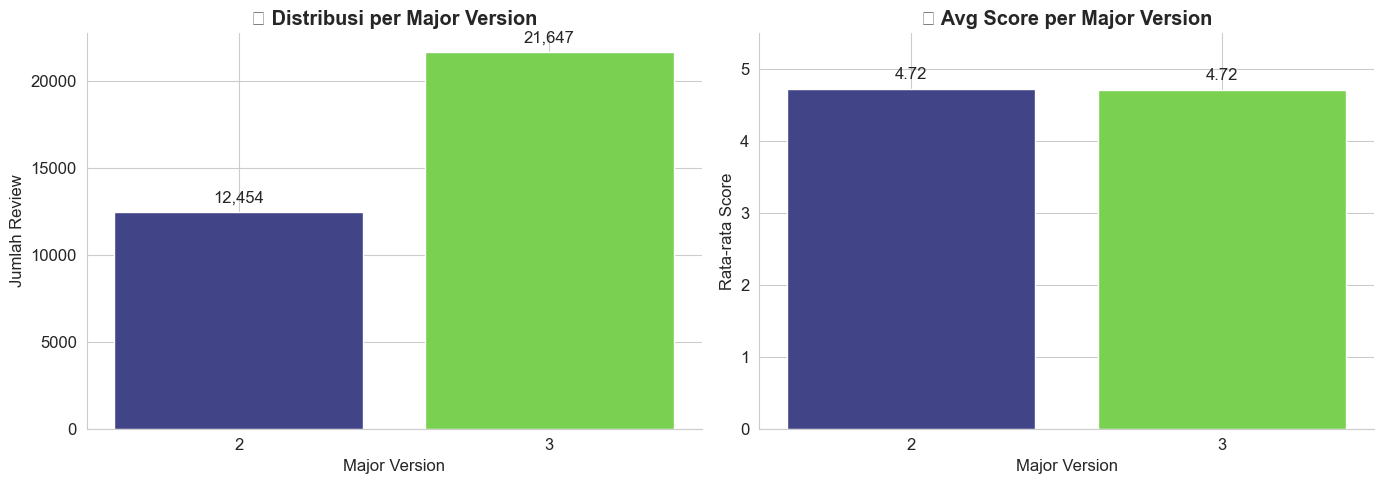


📌 Demo re.compile + named groups (groupdict):
   '3.831.0' → {'major': '3', 'minor': '831', 'patch': '0'}
   '3.833.1' → {'major': '3', 'minor': '833', 'patch': '1'}
   '3.825.1' → {'major': '3', 'minor': '825', 'patch': '1'}
   '3.812.2' → {'major': '3', 'minor': '812', 'patch': '2'}
   '3.779.6' → {'major': '3', 'minor': '779', 'patch': '6'}


In [37]:
# ── Compile pattern: major.minor.patch ──
pat_version = re.compile(r'(?P<major>\d+)\.(?P<minor>\d+)\.(?P<patch>\d+)')

# ── Ekstrak komponen versi ──
ver_parts = df['reviewCreatedVersion'].dropna().astype(str).apply(
    lambda v: pat_version.search(v)
)

df['ver_major'] = ver_parts.apply(lambda m: int(m.group('major')) if m else None)
df['ver_minor'] = ver_parts.apply(lambda m: int(m.group('minor')) if m else None)
df['ver_patch'] = ver_parts.apply(lambda m: int(m.group('patch')) if m else None)

print(f"📌 Versi berhasil diekstrak: {df['ver_major'].notna().sum():,} dari {len(df):,} review")
print(f"📌 Gagal diekstrak (NaN)   : {df['ver_major'].isna().sum():,}")

# ── Distribusi Major Version ──
major_dist = df['ver_major'].dropna().astype(int).value_counts().sort_index()
print(f"\n📊 Distribusi Major Version:")
for ver, cnt in major_dist.items():
    bar = '█' * int(cnt / major_dist.max() * 30)
    print(f"   v{ver}.x.x : {bar} {cnt:,}")

# ── Visualisasi ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Major version bar chart
colors_ver = plt.cm.viridis(np.linspace(0.2, 0.8, len(major_dist)))
bars = axes[0].bar(major_dist.index.astype(str), major_dist.values, color=colors_ver)
axes[0].bar_label(bars, fmt='{:,.0f}', padding=5)
axes[0].set_xlabel('Major Version')
axes[0].set_ylabel('Jumlah Review')
axes[0].set_title('📊 Distribusi per Major Version', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Avg score per major version
avg_by_major = df.groupby('ver_major')['score'].mean().sort_index()
bars2 = axes[1].bar(avg_by_major.index.astype(int).astype(str), avg_by_major.values,
                     color=colors_ver[:len(avg_by_major)])
axes[1].bar_label(bars2, fmt='{:.2f}', padding=5)
axes[1].set_xlabel('Major Version')
axes[1].set_ylabel('Rata-rata Score')
axes[1].set_title('⭐ Avg Score per Major Version', fontweight='bold')
axes[1].set_ylim(0, 5.5)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── Demo groupdict ──
print("\n📌 Demo re.compile + named groups (groupdict):")
sample_versions = df['reviewCreatedVersion'].dropna().unique()[:5]
for sv in sample_versions:
    m = pat_version.search(str(sv))
    if m:
        print(f"   '{sv}' → {m.groupdict()}")

## 7) 📖 Interpretasi N = Review per Tahun

Dari visualisasi di atas, kita dapat mengamati:

1. **2024 adalah puncak review** — tahun dengan jumlah review terbanyak, menandakan periode pertumbuhan pengguna aktif aplikasi Honest
2. **2023 sebagai awal adopsi** — review mulai banyak masuk sejak 2023, menunjukkan fase awal akuisisi pengguna
3. **2025 mengalami penurunan** — jumlah review menurun dibanding 2024, bisa mengindikasikan stabilisasi atau churn pengguna
4. **2026 masih parsial** — data hanya mencakup awal tahun sehingga belum bisa dibandingkan langsung
5. **Average score bervariasi** — setiap tahun memiliki rata-rata score yang berbeda, menunjukkan perubahan sentimen pengguna seiring waktu

## 8) 📊 Distribusi Score per Tahun

Melihat sebaran rating pengguna untuk setiap tahun menggunakan **countplot** (mengikuti pola rezkyyayang: `sns.countplot(x='year', hue='score')`).

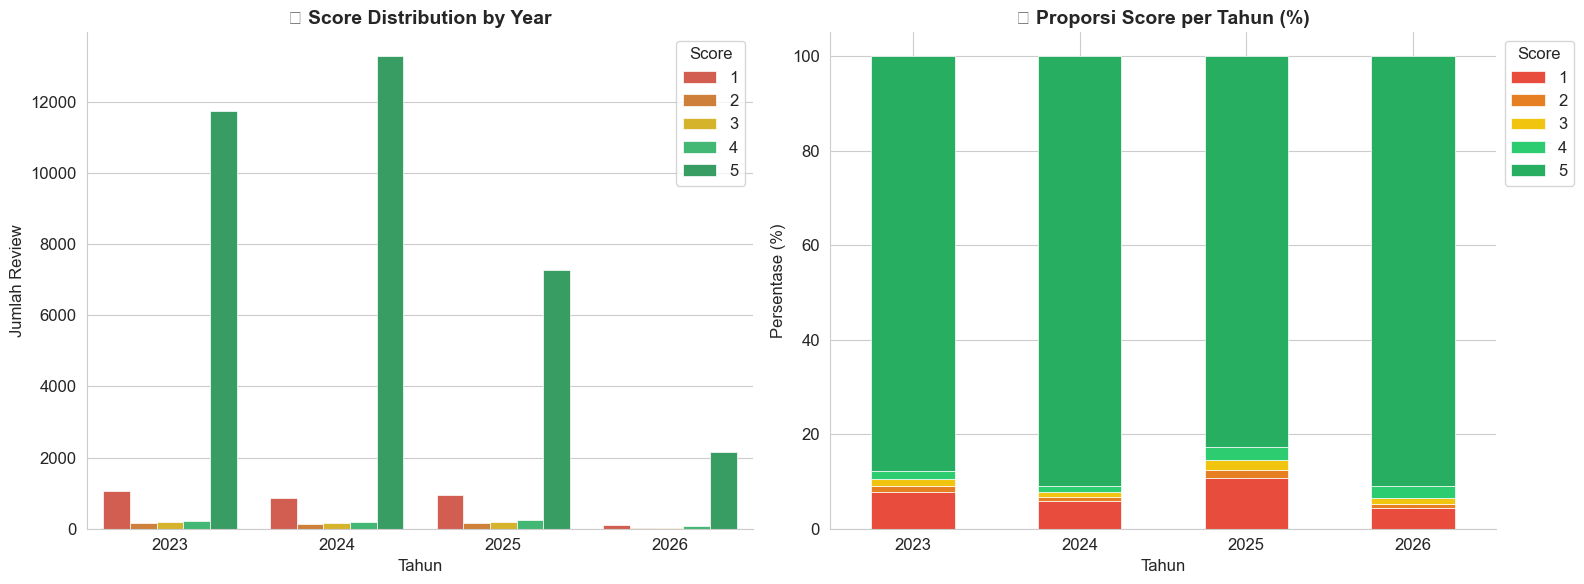

📌 2023: Score 5 = 87.7%, Score 1 = 7.9%
📌 2024: Score 5 = 91.0%, Score 1 = 5.8%
📌 2025: Score 5 = 82.6%, Score 1 = 10.8%
📌 2026: Score 5 = 90.9%, Score 1 = 4.4%


In [38]:
# ── Distribusi Score per Tahun (countplot gaya rezkyyayang + stacked) ──
colors_score = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
ct_year = pd.crosstab(df['year'], df['score'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Countplot (grouped bar) ──
sns.countplot(data=df, x='year', hue='score', palette=colors_score, ax=axes[0],
              edgecolor='white', linewidth=0.5)
axes[0].set_title('📊 Score Distribution by Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tahun', fontsize=12)
axes[0].set_ylabel('Jumlah Review', fontsize=12)
axes[0].legend(title='Score', bbox_to_anchor=(1.0, 1.0))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Stacked bar (proporsi %) ──
ct_pct = ct_year.div(ct_year.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colors_score,
            edgecolor='white', linewidth=0.5)
axes[1].set_title('📊 Proporsi Score per Tahun (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tahun', fontsize=12)
axes[1].set_ylabel('Persentase (%)', fontsize=12)
axes[1].legend(title='Score', bbox_to_anchor=(1.0, 1.0))
axes[1].tick_params(axis='x', rotation=0)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ── Insight ──
for yr in sorted(df['year'].unique()):
    s5_pct = ct_year.loc[yr, 5] / ct_year.loc[yr].sum() * 100
    s1_pct = ct_year.loc[yr, 1] / ct_year.loc[yr].sum() * 100
    print(f"📌 {yr}: Score 5 = {s5_pct:.1f}%, Score 1 = {s1_pct:.1f}%")

## 9) 📈 Tren Jumlah Review & Rata-rata Score per Tahun

Visualisasi dual-axis: bar chart = jumlah review, line chart = rata-rata score. Menunjukkan apakah pertumbuhan review diikuti dengan perubahan kepuasan pengguna.

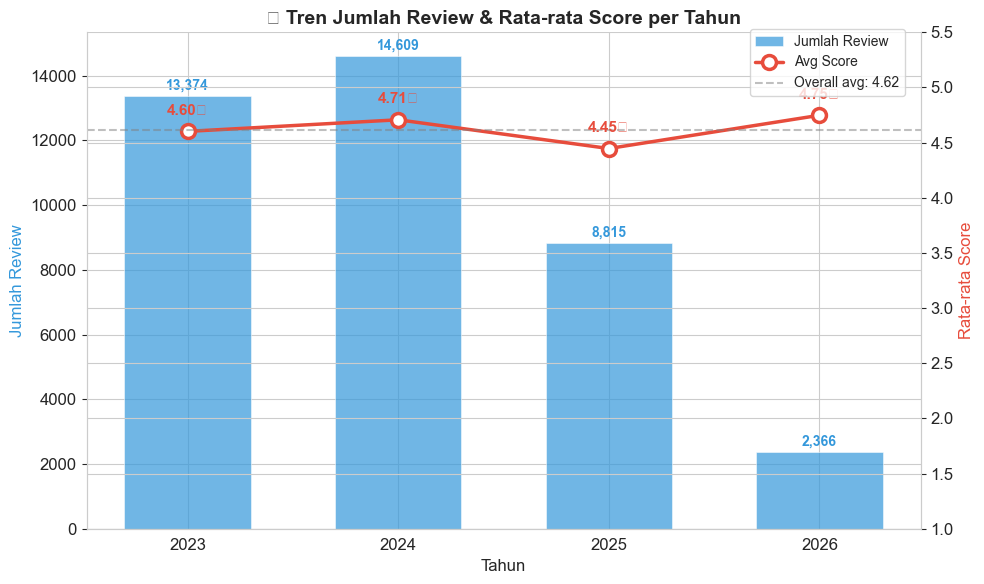


📌 Tahun dengan avg score tertinggi: 2026 (4.75⭐)
📌 Tahun dengan avg score terendah : 2025 (4.45⭐)
📌 Overall avg score: 4.62⭐


In [39]:
# ── Dual-axis: Jumlah Review & Avg Score per Tahun ──
year_stats = df.groupby('year')['score'].agg(['count', 'mean']).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar: jumlah review
color_bar = '#3498db'
bars = ax1.bar(year_stats['year'], year_stats['count'],
               color=color_bar, alpha=0.7, width=0.6,
               edgecolor='white', linewidth=0.5, label='Jumlah Review')
ax1.set_xlabel('Tahun', fontsize=12)
ax1.set_ylabel('Jumlah Review', color=color_bar, fontsize=12)
ax1.set_xticks(year_stats['year'])
ax1.spines['top'].set_visible(False)

# Annotate bar
for yr, cnt in zip(year_stats['year'], year_stats['count']):
    ax1.text(yr, cnt + 200, f'{cnt:,}', ha='center', fontsize=10, fontweight='bold', color=color_bar)

# Line: avg score
ax2 = ax1.twinx()
ax2.plot(year_stats['year'], year_stats['mean'],
         'o-', color='#e74c3c', linewidth=2.5, markersize=10,
         markerfacecolor='white', markeredgewidth=2.5,
         markeredgecolor='#e74c3c', label='Avg Score')
ax2.set_ylabel('Rata-rata Score', color='#e74c3c', fontsize=12)
ax2.set_ylim(1, 5.5)
ax2.axhline(y=df['score'].mean(), color='gray', linestyle='--', alpha=0.5,
            label=f"Overall avg: {df['score'].mean():.2f}")
ax2.spines['top'].set_visible(False)

# Annotate score
for yr, m in zip(year_stats['year'], year_stats['mean']):
    ax2.annotate(f'{m:.2f}⭐', (yr, m), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=11, fontweight='bold',
                 color='#e74c3c')

fig.legend(loc='upper right', bbox_to_anchor=(0.92, 0.95), fontsize=10)
plt.title('📊 Tren Jumlah Review & Rata-rata Score per Tahun', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Insight ──
best_avg = year_stats.loc[year_stats['mean'].idxmax()]
worst_avg = year_stats.loc[year_stats['mean'].idxmin()]
print(f"\n📌 Tahun dengan avg score tertinggi: {int(best_avg['year'])} ({best_avg['mean']:.2f}⭐)")
print(f"📌 Tahun dengan avg score terendah : {int(worst_avg['year'])} ({worst_avg['mean']:.2f}⭐)")
print(f"📌 Overall avg score: {df['score'].mean():.2f}⭐")

## 10) ☁️ WordCloud: Review Positif vs Negatif

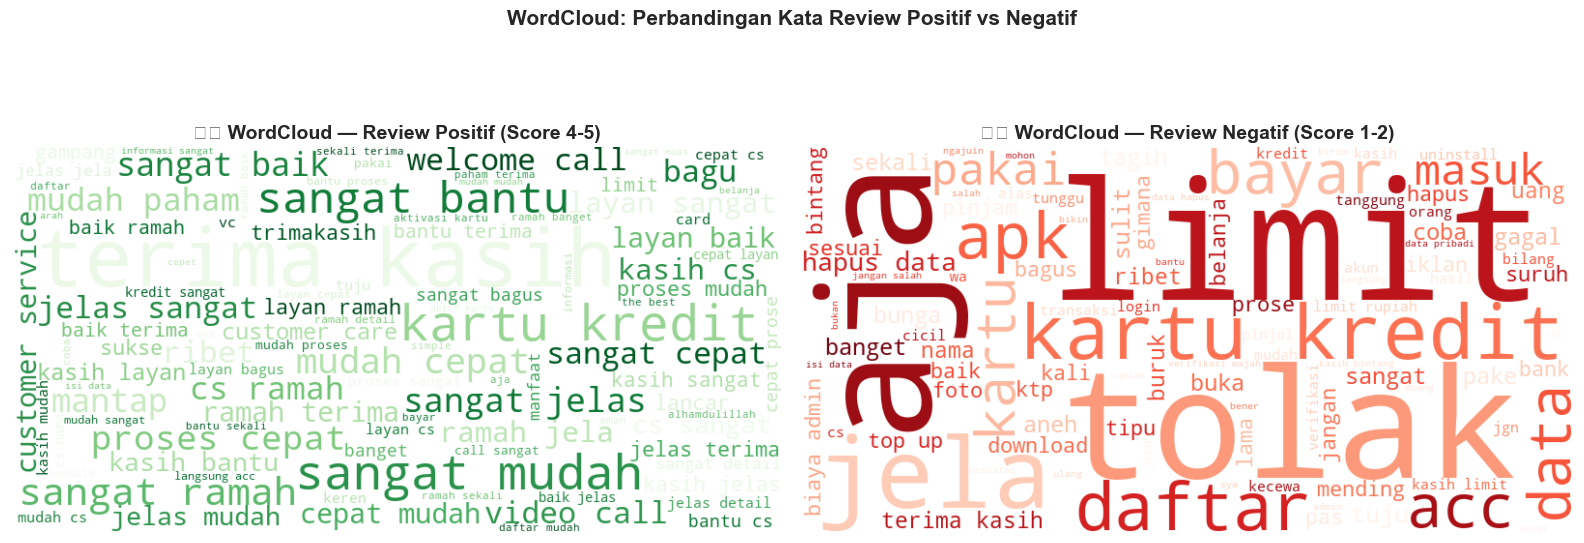


📌 Review positif (score 4-5): 35,178 (89.8%)
📌 Review negatif (score 1-2): 3,425 (8.7%)


In [40]:
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords_id = set(factory.get_stop_words())

pos_text = ' '.join(df[df['score'] >= 4]['text_final'].astype(str))
neg_text = ' '.join(df[df['score'] <= 2]['text_final'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', stopwords=stopwords_id, max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('☁️ WordCloud — Review Positif (Score 4-5)', fontsize=14, fontweight='bold')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', stopwords=stopwords_id, max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('☁️ WordCloud — Review Negatif (Score 1-2)', fontsize=14, fontweight='bold')

plt.suptitle('WordCloud: Perbandingan Kata Review Positif vs Negatif', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Insight ──
n_pos = len(df[df['score'] >= 4])
n_neg = len(df[df['score'] <= 2])
print(f"\n📌 Review positif (score 4-5): {n_pos:,} ({n_pos/len(df)*100:.1f}%)")
print(f"📌 Review negatif (score 1-2): {n_neg:,} ({n_neg/len(df)*100:.1f}%)")

## 11) 📝 Top 20 Kata Paling Sering Muncul

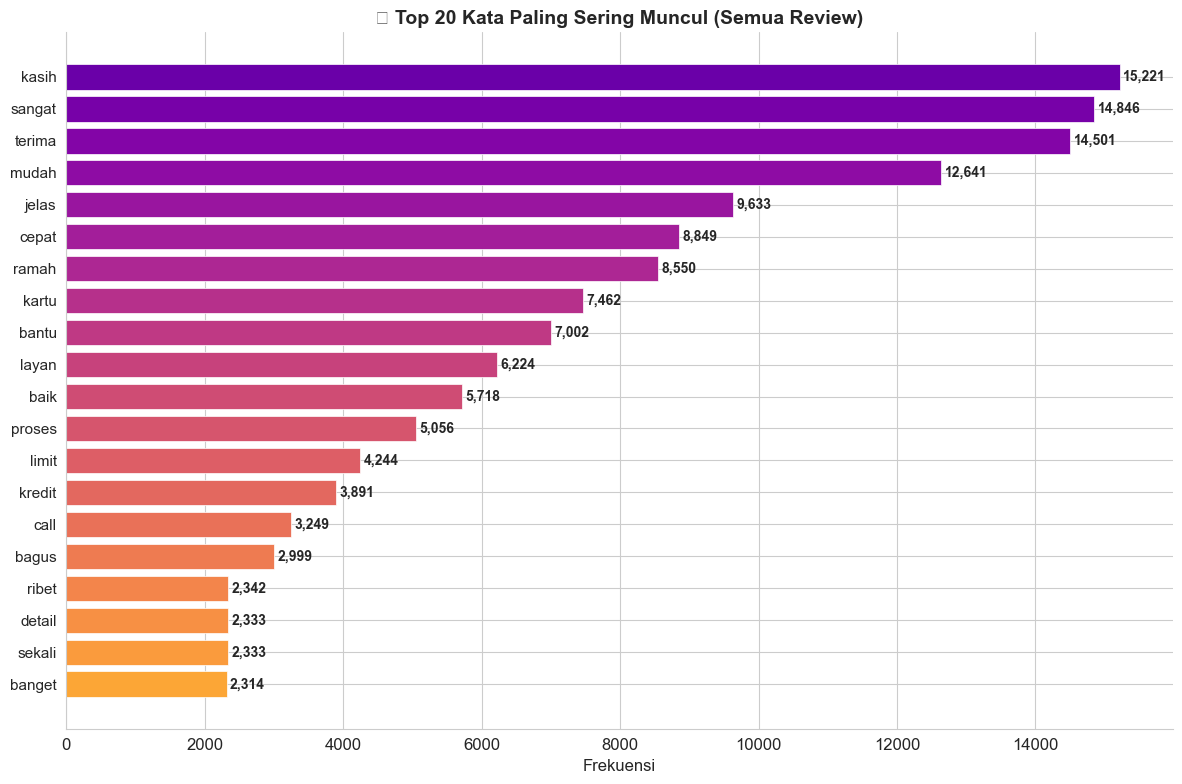


📌 Kata paling sering: 'kasih' (15,221 kemunculan)
📌 Total kata unik (setelah filter): 2,938


In [41]:
all_words = ' '.join(df['text_final'].astype(str)).split()
filtered = [w for w in all_words if w not in stopwords_id and len(w) > 2]
top_words = Counter(filtered).most_common(20)

words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(words)), counts,
               color=plt.cm.plasma(np.linspace(0.2, 0.8, len(words))),
               edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Frekuensi', fontsize=12)
ax.set_title('📊 Top 20 Kata Paling Sering Muncul (Semua Review)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, v in enumerate(counts):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Insight ──
print(f"\n📌 Kata paling sering: '{words[0]}' ({counts[0]:,} kemunculan)")
print(f"📌 Total kata unik (setelah filter): {len(set(filtered)):,}")

## ✅ Kesimpulan

1. **Scraping** review dari Google Play Store dapat dilakukan dengan `google-play-scraper`
2. **Merge dataset** — `cleandata.csv` digabung dengan `df_honest_reviews_id.csv` untuk mendapatkan kolom tanggal (`at`), menghasilkan dimensi temporal (tahun)
3. **Tren Review per Tahun** — 2024 menjadi puncak jumlah review, menandakan periode pertumbuhan pengguna. 2025 mulai menurun, sementara 2026 masih parsial
4. **Distribusi Score per Tahun** — Score 5 konsisten mendominasi di setiap tahun (>80%), namun proporsi score rendah (1-2) meningkat di tahun 2025
5. **Dual-axis chart** menunjukkan tahun dengan review terbanyak tidak selalu memiliki rata-rata score tertinggi
6. **WordCloud** mengkonfirmasi perbedaan topik antara review positif (fitur, kemudahan) dan negatif (masalah, error)
7. **Regex Version Extraction** — Pattern `(?P<major>\d+)\.(?P<minor>\d+)\.(?P<patch>\d+)` mengekstrak **34,101 versi** dari 39,164 review. Major version v3.x.x mendominasi (**21,647 review**) vs v2.x.x (**12,454 review**), dengan rata-rata score identik (**4.72**) menunjukkan transisi versi major tidak memengaruhi kepuasan pengguna.
8. **Referensi** — Pola analisis temporal mengikuti notebook [data-analysis-on-indonesia-startup-apps-reviews](https://github.com/rezkyyayang) oleh Rezky Yayang

---